# Examples for McKean-Vlasov control

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.special import beta

## Initial distributions

In [3]:
def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)

    result = 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1
    result += 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2
    
    return result

## Benedetto et al. (1998)

Consider $G(x) = \beta \frac{(x-\pi)^2}{2}$ and $W(x) = \lambda |x-\pi|^3$ over the interval $[0, 2\pi]$. 

The McKean-Vlasov equation with these functions is the homogeneous version of the transport equation in a thermal bath with temperature $\beta^{-1}$ that can be derived from inelastic collisions. 

In [3]:
G = lambda x: 5 * (x - np.pi)**2
W = lambda x: np.abs(x-np.pi)**3

alpha1 = lambda x: np.sin(x) / np.sqrt(4 * np.pi) 
alpha2 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
alpha3 = lambda x: np.sin(2*x) / np.sqrt(4 * np.pi) 
alpha4 = lambda x: np.cos(2*x) / np.sqrt(4 * np.pi) 

nabla_alpha1 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
nabla_alpha2 = lambda x: -np.sin(x) / np.sqrt(4 * np.pi) 
nabla_alpha3 = lambda x: 2 * np.cos(2*x) / np.sqrt(4 * np.pi) 
nabla_alpha4 = lambda x: -2 * np.sin(2*x) / np.sqrt(4 * np.pi) 

def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x):
    alpha_param1 = 4.0
    beta_param1 = 2.0
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)

    alpha_param2 = 2.0
    beta_param2 = 10.0
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)
    return 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1 + 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2

Solving the equation. 

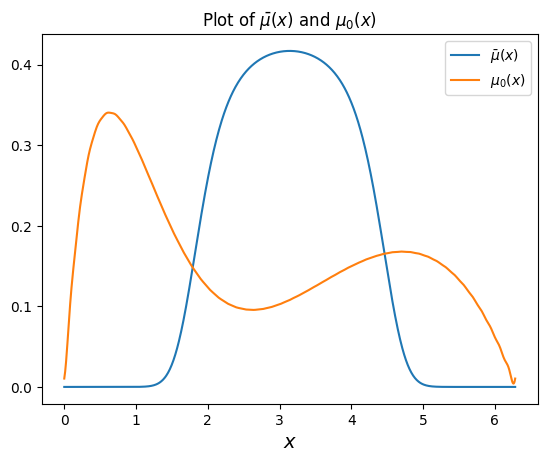

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.16.
MESSAGE - Nonlinear equation solved in 5.78.


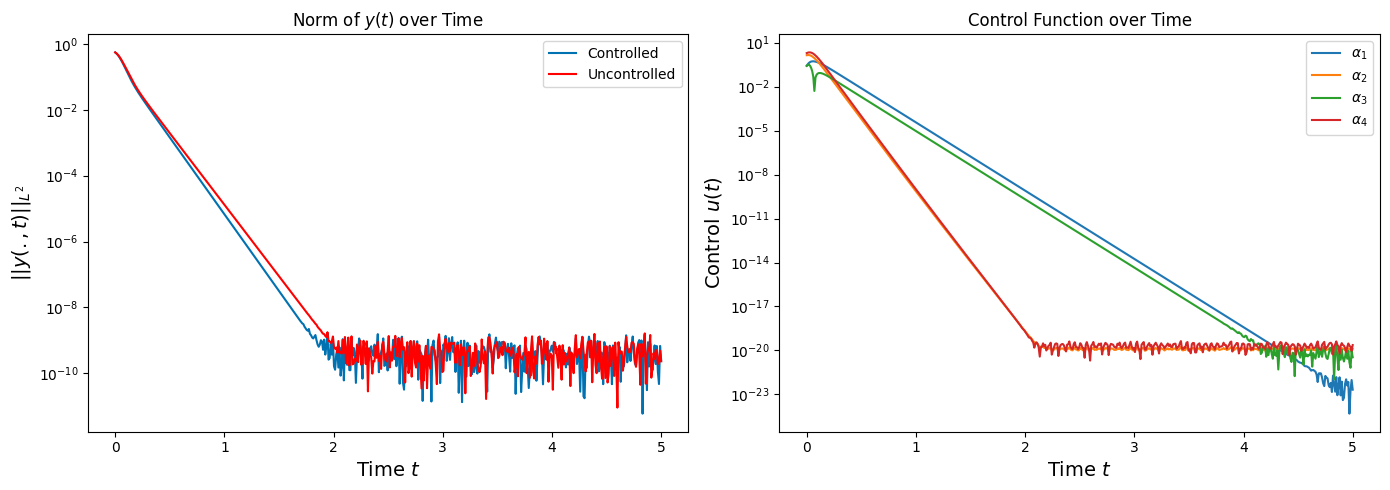

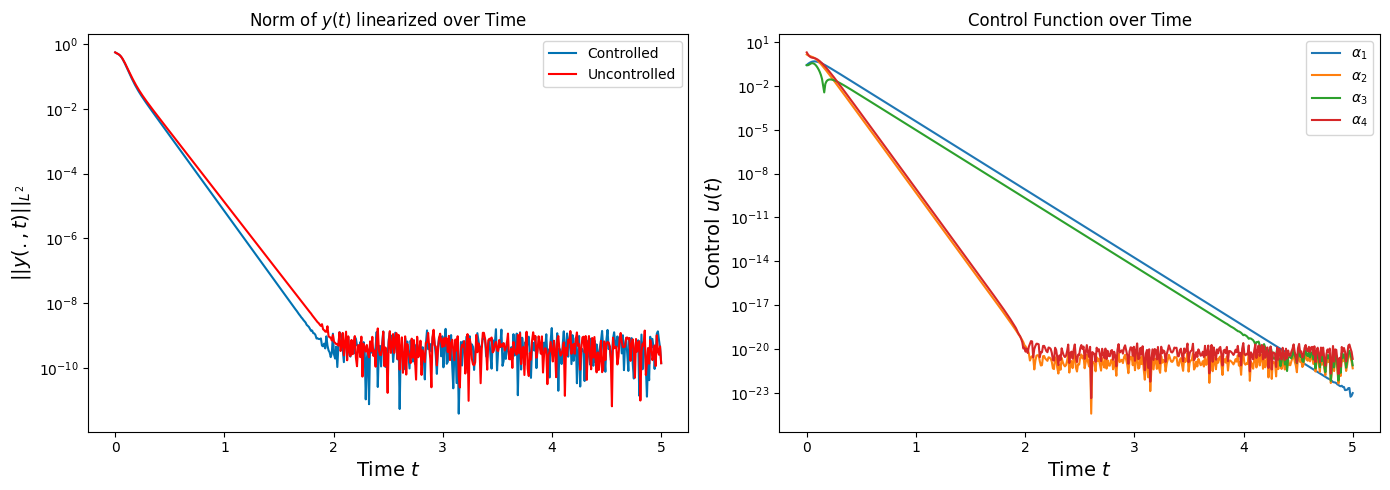

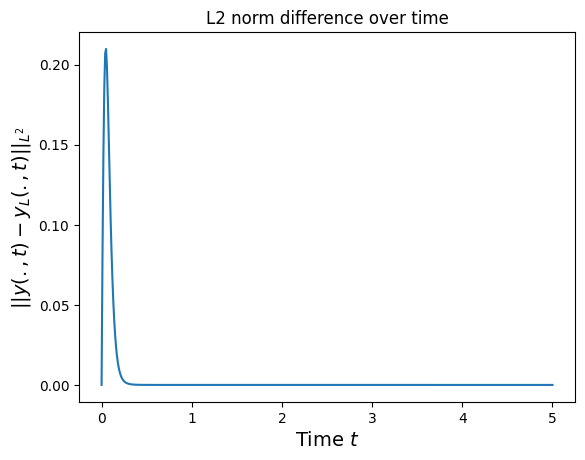

In [4]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=5.0)
plotter.plot_control_and_norm_linear(t_max=5.0)
plotter.plot_y_diff_L2_norm(t_max=5.0)

Consider now a smaller value of $\beta$ (so a higher temperature). 

In [5]:
G = lambda x: 1e-8 * (x - np.pi)**2

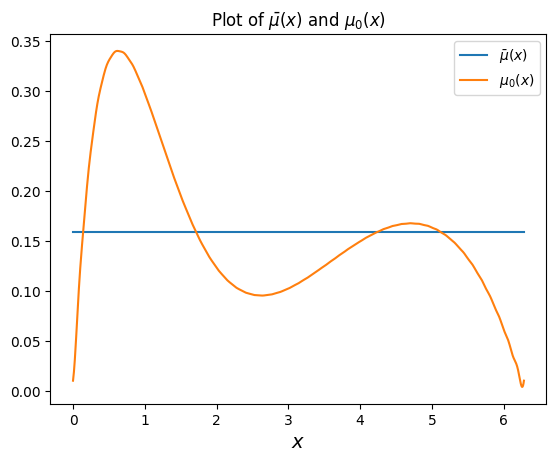

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.15.
MESSAGE - Nonlinear equation solved in 5.93.


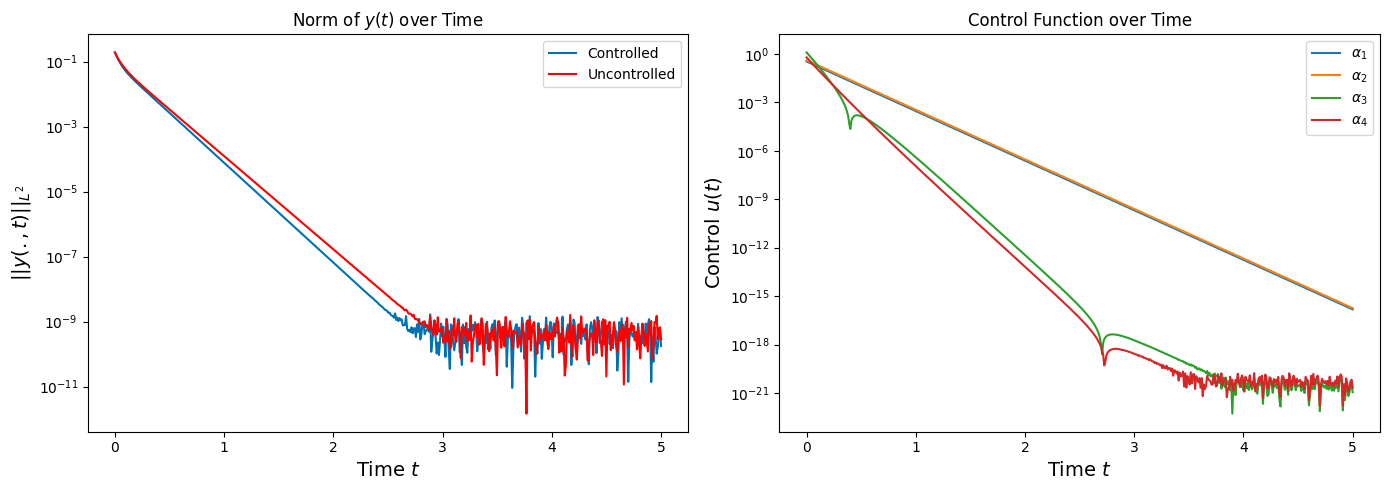

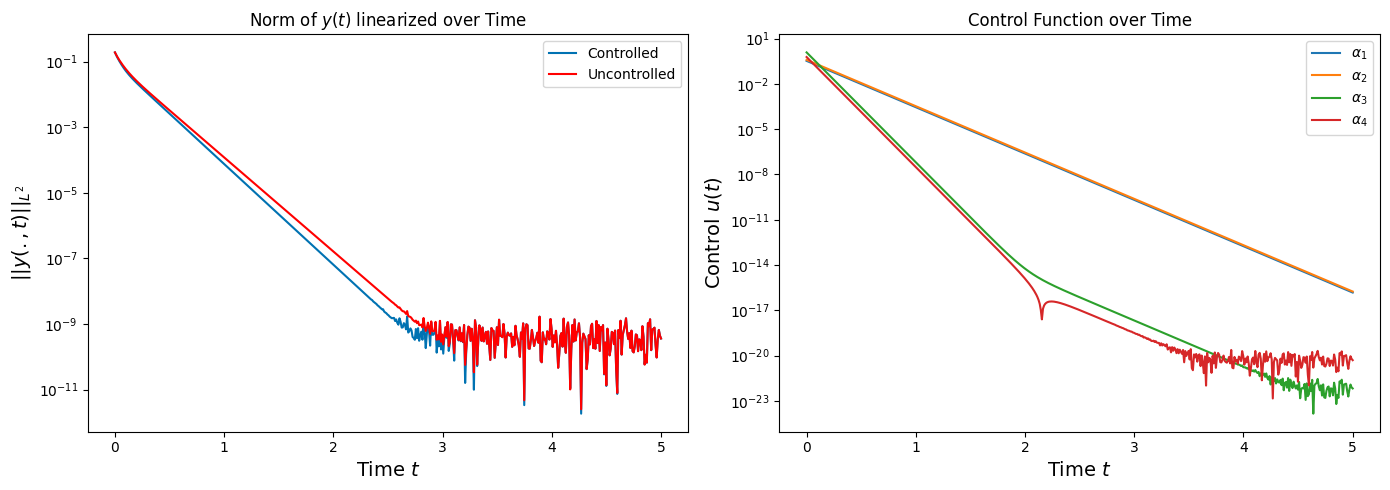

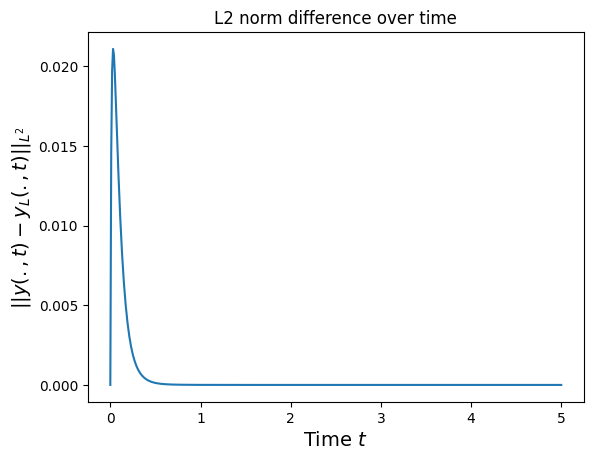

In [6]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)

plotter.plot_mu_bar_x()
plotter.plot_control_and_norm(t_max=5.0)
plotter.plot_control_and_norm_linear(t_max=5.0)
plotter.plot_y_diff_L2_norm(t_max=5.0)

## O(2) model with magnetic field

Consider $G(x) = -\eta \cos(2\pi x)$ and $W(x) = -\cos(2\pi x)$ over the interval $[0, 2\pi]$.
Moreover we have that $\sigma = \sqrt{\beta^{-1}}$ is the temperature of the system. For a sufficient high temperature, there exists a unique stable steady state.

## Kuramoto model

Consider $G(x) = 0$ and $W(x) = -K \cos(x)$. First, $K = 1$. 

In [4]:
G = lambda x: np.zeros_like(x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

In [17]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)

plotter = McKeanVlasovPlotter(solver)

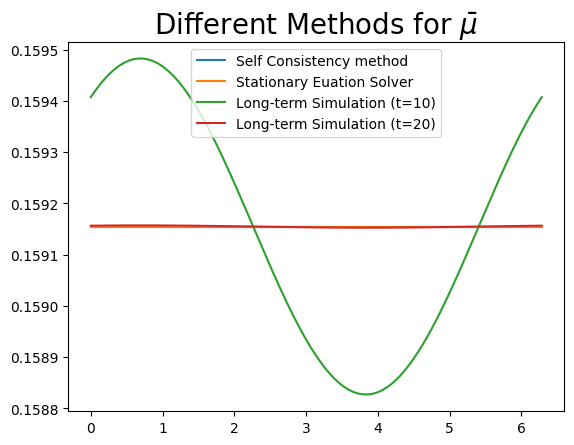

In [18]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 20), t_eval=(10, 20,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=10)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=20)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

For this example, we expect the density to converge to the uniform distribution. By using control on the linearsed equation, we can accelerate this convergence. Here, for example, in 2 seconds, we achieve the L2 norm of $10^{-9}$, while without control we would get something higher than $10^{-3}$. 

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.13.
MESSAGE - Nonlinear equation solved in 6.34.


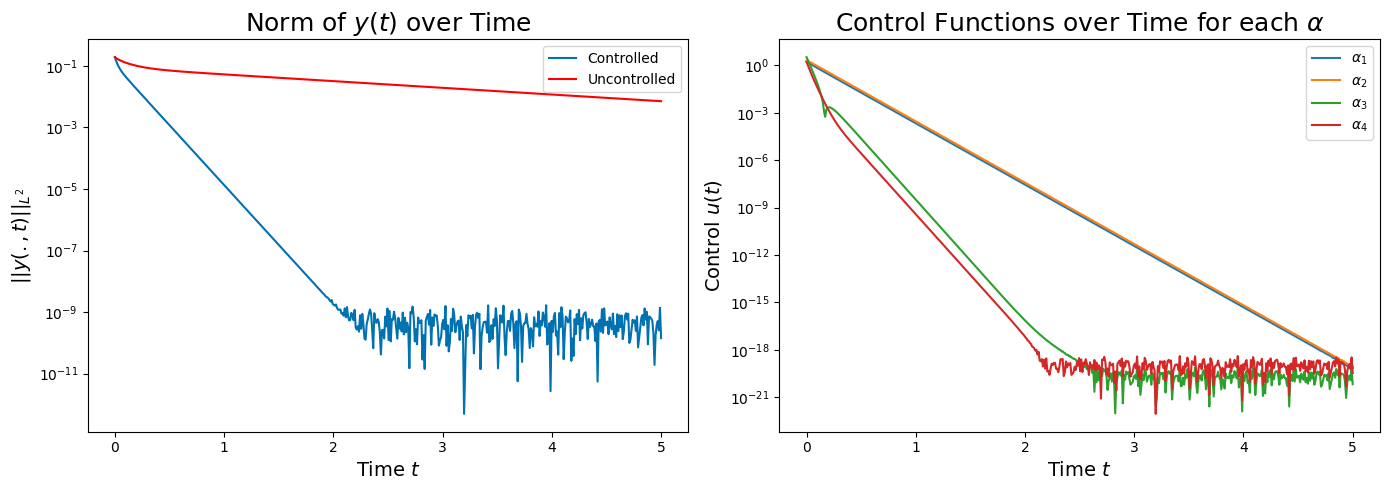

In [19]:
plotter.plot_control_and_norm(t_max=5.0)

For $K=5$, the situation is different. There is the presence of a second stationary distribution and the uniform one turns out to be unstable. Let's see what is means to linearise around the **unstable** steady state. 

In [21]:
G = lambda x: np.zeros_like(x)
W = lambda x: -5*np.cos(x)

solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)

plotter = McKeanVlasovPlotter(solver)

Notice that the methods disagree on the solution, which was something possible as discussed. For this case, the convergence to the **stable** steady state is very fast.

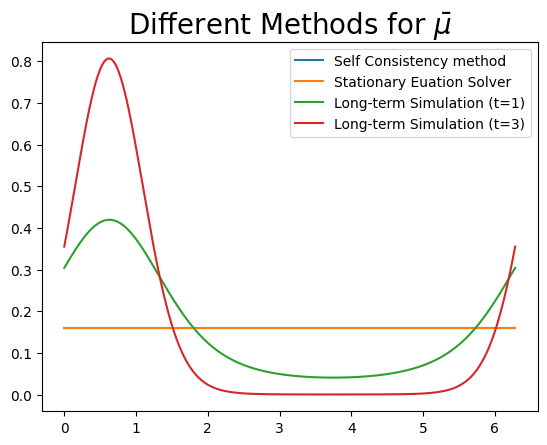

In [25]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 3), t_eval=(1, 3,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=1)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=3)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

Controlling the equation leads to a situation where we are able to bring the solution close to the unstable steady state.

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.19.
MESSAGE - Nonlinear equation solved in 6.26.


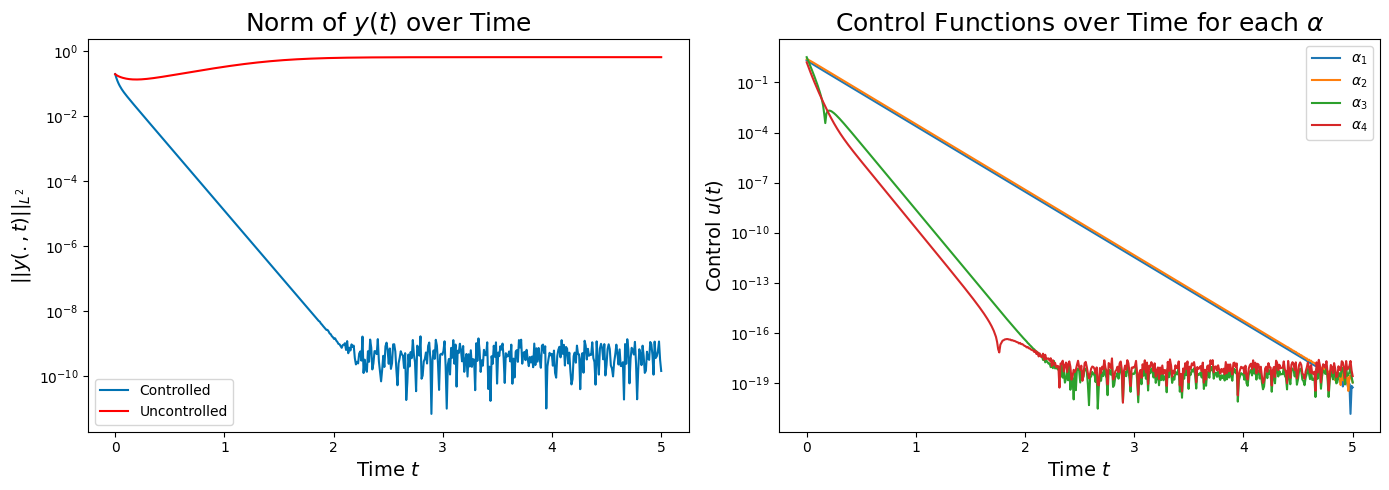

In [26]:
plotter.plot_control_and_norm(t_max=5.0)

Let us change the model a little bit to include a non-zero potential $G$. The situation will be similar, though

In [27]:
eta = 0.5
G = lambda x: eta * np.cos(x)
W_smaller = lambda x: -0.5 * np.cos(x)
W_higher = lambda x: -5 * np.cos(x)

solver_smaller = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                    W=W_smaller, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, 
                                    grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                    state_weight=100000)

solver_higher = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                    W=W_higher, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, 
                                    grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                    state_weight=100000)

In [28]:
a_bar_smaller = solver_smaller.nonlinear_controlled_solver_mu(t_span=(0, 20), t_eval=(20,), u=lambda t,a: np.zeros(4))
a_bar_higher = solver_higher.nonlinear_controlled_solver_mu(t_span=(0, 20), t_eval=(20,), u=lambda t,a: np.zeros(4))

mu_bar_smaller = solver_smaller.reconstruction(a_bar_smaller.y[:,-1], x)
mu_bar_sc_smaller = solver_smaller.reconstruction(solver_smaller.bar_mu_k, x)

mu_bar_higher = solver_higher.reconstruction(a_bar_higher.y[:,-1], x)
mu_bar_sc_higher = solver_higher.reconstruction(solver_higher.bar_mu_k, x)

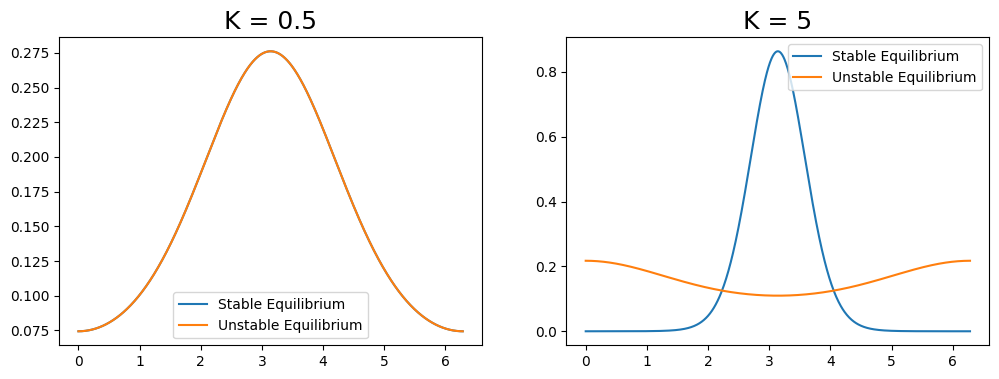

In [34]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(x, mu_bar_smaller, label="Stable Equilibrium")
ax[0].plot(x, mu_bar_sc_smaller, label="Unstable Equilibrium")

ax[1].plot(x, mu_bar_higher, label="Stable Equilibrium")
ax[1].plot(x, mu_bar_sc_higher, label="Unstable Equilibrium")

ax[0].set_title("K = 0.5", fontsize=18)
ax[1].set_title("K = 5", fontsize=18)

ax[0].legend()
ax[1].legend()
plt.show()

In [51]:
eta = 0.5
G = lambda x: eta * np.cos(x)
W = lambda x: -3.1*np.cos(x)

solver = McKeanVlasovSolver(L=80, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)

plotter = McKeanVlasovPlotter(solver)

WARNING - Method Self-Consistency Method didn't work.
Error: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.


ValueError: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.

In [ ]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 10), t_eval=(1, 10,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=1)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

WARNING - Method Self-Consistency Method didn't work.
Error: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.


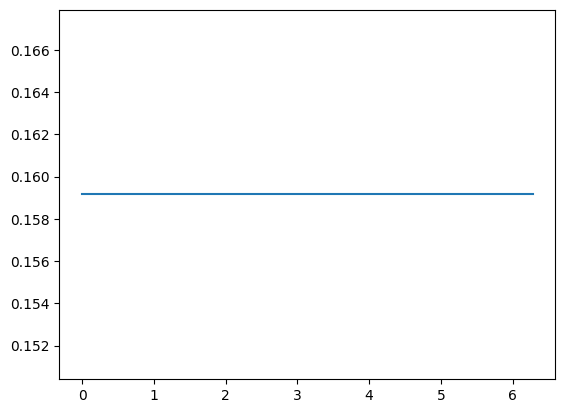

WARNING - Method Self-Consistency Method didn't work.
Error: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.


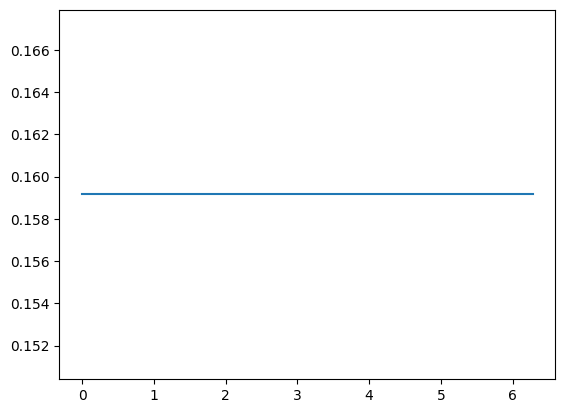

WARNING - Method Self-Consistency Method didn't work.
Error: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.


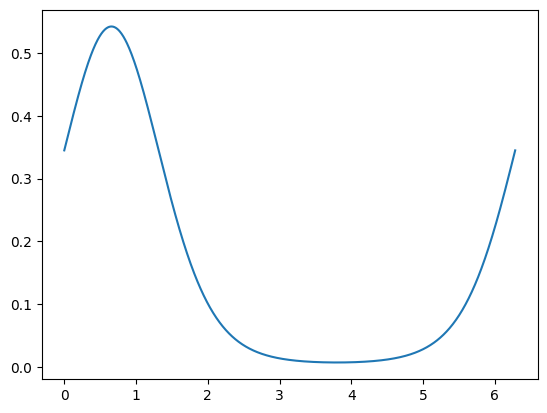

WARNING - Method Self-Consistency Method didn't work.
Error: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.


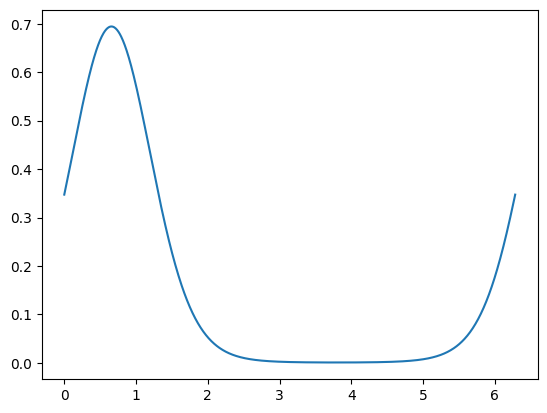

WARNING - Method Self-Consistency Method didn't work.
Error: Nonlinear solver did not converge: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.


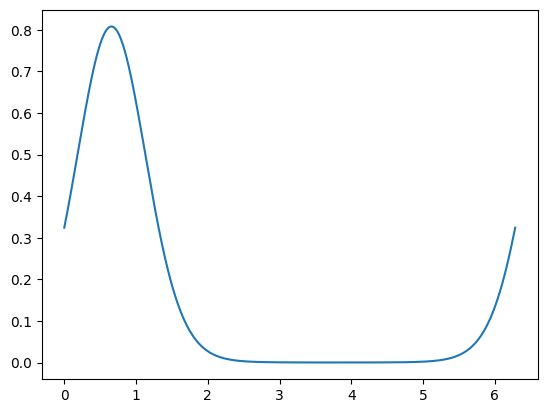

In [89]:
W_functions = [lambda x: -1.1 * np.cos(x),
               lambda x: -1.7 * np.cos(x),
               lambda x: -3 * np.cos(x),
               lambda x: -4 * np.cos(x),
               lambda x: -5 * np.cos(x),]

solvers = []

solver = McKeanVlasovSolver(L=100, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W_functions[2], mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

a_bar = solver.nonlinear_controlled_solver_mu(t_span=(0, 20), t_eval=(20,), u=lambda t,a: np.zeros(4))

for i, W in enumerate(W_functions):

    solver = McKeanVlasovSolver(L=100, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000, bar_mu_k_initial=a_bar.y[:,0])
    solvers.append(solver)

    mu_bar = solver.reconstruction(solver.bar_mu_k, x)
    plt.plot(x, mu_bar)
    plt.gca().yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    plt.show()

In [90]:
sol1_c = solvers[0].solve_control_problem(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))
sol1_u = solvers[0].nonlinear_uncontrolled_solver_y(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))

y_norm1_c = np.linalg.norm(sol1_c.y, axis=0)
y_norm1_u = np.linalg.norm(sol1_u.y, axis=0)

sol2_c = solvers[1].solve_control_problem(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))
sol2_u = solvers[1].nonlinear_uncontrolled_solver_y(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))

y_norm2_c = np.linalg.norm(sol2_c.y, axis=0)
y_norm2_u = np.linalg.norm(sol2_u.y, axis=0)

sol3_c = solvers[2].solve_control_problem(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))
sol3_u = solvers[2].nonlinear_uncontrolled_solver_y(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))

y_norm3_c = np.linalg.norm(sol3_c.y, axis=0)
y_norm3_u = np.linalg.norm(sol3_u.y, axis=0)

sol4_c = solvers[3].solve_control_problem(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))
sol4_u = solvers[3].nonlinear_uncontrolled_solver_y(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))

y_norm4_c = np.linalg.norm(sol4_c.y, axis=0)
y_norm4_u = np.linalg.norm(sol4_u.y, axis=0)

sol5_c = solvers[4].solve_control_problem(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))
sol5_u = solvers[4].nonlinear_uncontrolled_solver_y(t_span=(0, 5), t_eval=np.linspace(0, 5, 100))

y_norm5_c = np.linalg.norm(sol5_c.y, axis=0)
y_norm5_u = np.linalg.norm(sol5_u.y, axis=0)

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.77.
MESSAGE - Nonlinear equation solved in 76.20.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.76.
MESSAGE - Nonlinear equation solved in 75.41.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.80.
MESSAGE - Nonlinear equation solved in 74.77.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.82.
MESSAGE - Nonlinear equation solved in 76.83.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Ricatti equation solved in 0.90.
MESSAGE - Nonlinear equation solved in 73.59.


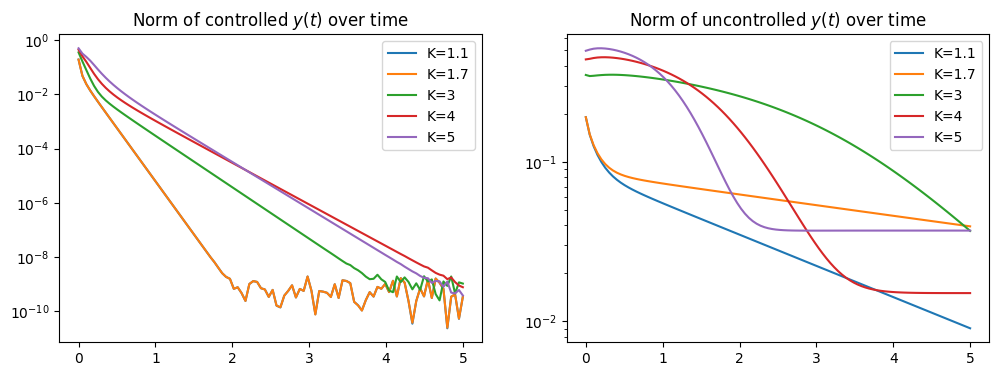

In [91]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(sol1_c.t, y_norm1_c, label="K=1.1")
ax[0].plot(sol1_c.t, y_norm2_c, label="K=1.7")
ax[0].plot(sol1_c.t, y_norm3_c, label="K=3")
ax[0].plot(sol1_c.t, y_norm4_c, label="K=4")
ax[0].plot(sol1_c.t, y_norm5_c, label="K=5")
ax[0].legend()
ax[0].set_yscale('log')
ax[0].set_title('Norm of controlled $y(t)$ over time')

ax[1].plot(sol1_c.t, y_norm1_u, label="K=1.1")
ax[1].plot(sol1_c.t, y_norm2_u, label="K=1.7")
ax[1].plot(sol1_c.t, y_norm3_u, label="K=3")
ax[1].plot(sol1_c.t, y_norm4_u, label="K=4")
ax[1].plot(sol1_c.t, y_norm5_u, label="K=5")
ax[1].legend()
ax[1].set_yscale('log')
ax[1].set_title('Norm of uncontrolled $y(t)$ over time')

plt.show()